Dataset Slicer (Metadata Export)
---
The slicer is modified to track the bounding box of every generated tile and export a slice_metadata.json file. This is required for the raycaster to know where each slice originated on the parent sensor.

In [3]:
import os
import cv2
import json
from tqdm import tqdm
import random

def prepare_sliced_dataset_shiftback(input_dir, output_dir, slice_size=1024, overlap_ratio=0.2, min_area_ratio=0.2, class_names=None, train_bg_prob=0.10, val_bg_prob=1.0, test_bg_prob=1.0):
    valid_extensions = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')
    stride = int(slice_size * (1 - overlap_ratio))
    
    image_dir = os.path.join(input_dir, 'images') if os.path.isdir(os.path.join(input_dir, 'images')) else input_dir
    label_dir = os.path.join(input_dir, 'labels') if os.path.isdir(os.path.join(input_dir, 'labels')) else input_dir

    standard_splits = ['train', 'val', 'test']
    found_splits = [split for split in standard_splits if os.path.isdir(os.path.join(image_dir, split))]
    if not found_splits:
        found_splits = [''] 

    slice_metadata = {}

    for split in found_splits:
        img_split_dir = os.path.join(image_dir, split)
        lbl_split_dir = os.path.join(label_dir, split)
        
        out_img_dir = os.path.join(output_dir, 'images', split)
        out_lbl_dir = os.path.join(output_dir, 'labels', split)
        
        os.makedirs(out_img_dir, exist_ok=True)
        os.makedirs(out_lbl_dir, exist_ok=True)

        image_files = [f for f in os.listdir(img_split_dir) if f.lower().endswith(valid_extensions)]
        desc_text = f"Slicing {split}" if split else "Slicing Dataset"

        if split == 'val': current_bg_prob = val_bg_prob
        elif split == 'test': current_bg_prob = test_bg_prob
        else: current_bg_prob = train_bg_prob

        for img_name in tqdm(image_files, desc=desc_text):
            img_path = os.path.join(img_split_dir, img_name)
            base_name = os.path.splitext(img_name)[0]
            lbl_path = os.path.join(lbl_split_dir, f"{base_name}.txt")

            image = cv2.imread(img_path)
            if image is None: continue
            h, w, _ = image.shape

            if h < slice_size or w < slice_size:
                print(f"\nSkipping {img_name}: Resolution ({w}x{h}) is smaller than slice_size ({slice_size}).")
                continue

            yolo_coords = []
            if os.path.exists(lbl_path):
                with open(lbl_path, 'r') as f:
                    yolo_coords = [line.strip().split() for line in f.readlines() if line.strip()]

            x_starts = sorted(list(set([x for x in range(0, w - slice_size, stride)] + [w - slice_size])))
            y_starts = sorted(list(set([y for y in range(0, h - slice_size, stride)] + [h - slice_size])))

            for y_start in y_starts:
                for x_start in x_starts:
                    y_end = y_start + slice_size
                    x_end = x_start + slice_size
                    
                    tile_img = image[y_start:y_end, x_start:x_end]
                    tile_filename = f"{base_name}_{x_start}_{y_start}"
                    
                    tile_labels = []
                    for cls_data in yolo_coords:
                        if len(cls_data) < 5: continue
                        cls, x_c, y_c, bw, bh = cls_data
                        
                        px_c, py_c = float(x_c) * w, float(y_c) * h
                        pbw, pbh = float(bw) * w, float(bh) * h
                        
                        x_min = px_c - (pbw / 2)
                        x_max = px_c + (pbw / 2)
                        y_min = py_c - (pbh / 2)
                        y_max = py_c + (pbh / 2)
                        
                        original_area = pbw * pbh
                        
                        if x_min < x_end and x_max > x_start and y_min < y_end and y_max > y_start:
                            inter_x_min = max(x_min, x_start)
                            inter_x_max = min(x_max, x_end)
                            inter_y_min = max(y_min, y_start)
                            inter_y_max = min(y_max, y_end)
                            
                            local_x_min = inter_x_min - x_start
                            local_x_max = inter_x_max - x_start
                            local_y_min = inter_y_min - y_start
                            local_y_max = inter_y_max - y_start
                            
                            local_w = local_x_max - local_x_min
                            local_h = local_y_max - local_y_min
                            local_cx = local_x_min + (local_w / 2)
                            local_cy = local_y_min + (local_h / 2)
                            
                            clipped_area = local_w * local_h
                            completeness_ratio = clipped_area / original_area if original_area > 0 else 0
                            
                            new_xc = local_cx / slice_size
                            new_yc = local_cy / slice_size
                            new_bw = local_w / slice_size
                            new_bh = local_h / slice_size
                            
                            if new_bw > 0.005 and new_bh > 0.005 and completeness_ratio >= min_area_ratio:
                                tile_labels.append(f"{cls} {new_xc:.6f} {new_yc:.6f} {new_bw:.6f} {new_bh:.6f}")

                    saved = False
                    if tile_labels:
                        cv2.imwrite(os.path.join(out_img_dir, f"{tile_filename}.jpg"), tile_img)
                        with open(os.path.join(out_lbl_dir, f"{tile_filename}.txt"), 'w') as f:
                            f.write("\n".join(tile_labels))
                        saved = True
                    else:
                        if random.random() < current_bg_prob:
                            cv2.imwrite(os.path.join(out_img_dir, f"{tile_filename}.jpg"), tile_img)
                            open(os.path.join(out_lbl_dir, f"{tile_filename}.txt"), 'w').close()
                            saved = True
                    
                    if saved:
                        slice_metadata[tile_filename] = {
                            "parent_image": base_name,
                            "x_start": x_start,
                            "y_start": y_start,
                            "x_end": x_end,
                            "y_end": y_end,
                            "split_source": split
                        }

    metadata_path = os.path.join(output_dir, "slice_metadata.json")
    with open(metadata_path, 'w') as f:
        json.dump(slice_metadata, f, indent=4)
        
    print(f"\nSlicing finished. Metadata saved to {metadata_path}")

if __name__ == "__main__":
    prepare_sliced_dataset_shiftback(
        input_dir = r"C:\Users\emilb\_data\dataset_fin\combined",
        output_dir = r"C:\Users\emilb\_data\dataset_fin\sliced_dataset",
        slice_size = 1024,
        class_names = ["A. altissima"]
    )

Slicing Dataset: 100%|███████████████████████████████████████████████████████| 788/788 [18:42<00:00,  1.42s/it]



Slicing finished. Metadata saved to C:\Users\emilb\_data\dataset_fin\sliced_dataset\slice_metadata.json


Raycaster (Targeted Slice Coordinates)
---
This script reads the slice metadata, unprojects the local tile bounds relative to the parent sensor, and intersects them with the 3D mesh.

In [1]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import open3d as o3d
import json
import hashlib
import csv
from pyproj import Transformer

def generate_color(seed_string):
    hash_object = hashlib.md5(seed_string.encode('utf-8'))
    return f"#{hash_object.hexdigest()[:6]}"

def parse_metashape_xml(xml_path):
    print(f"Parsing Metashape XML: {os.path.basename(xml_path)}...")
    sensors = {}
    cameras = {}
    T_comp = np.eye(4)
    
    context = ET.iterparse(xml_path, events=('end',))
    
    for event, elem in context:
        if elem.tag == 'sensor':
            s_id = elem.get('id')
            res = elem.find('resolution')
            calib = elem.find('calibration')
            if res is not None and calib is not None:
                f = float(calib.find('f').text)
                cx = float(calib.find('cx').text) if calib.find('cx') is not None else 0.0
                cy = float(calib.find('cy').text) if calib.find('cy') is not None else 0.0
                sensors[s_id] = {
                    'w': float(res.get('width')), 
                    'h': float(res.get('height')), 
                    'f': f, 'cx': cx, 'cy': cy
                }
            elem.clear()

        elif elem.tag == 'component':
            transform = elem.find('transform')
            if transform is not None:
                rot = transform.find('rotation')
                trans = transform.find('translation')
                scl = transform.find('scale')
                if rot is not None and trans is not None and scl is not None:
                    rot_mat = np.array(list(map(float, rot.text.split()))).reshape(3, 3)
                    t_vec = np.array(list(map(float, trans.text.split())))
                    scale = float(scl.text)
                    T_comp[:3, :3] = rot_mat * scale
                    T_comp[:3, 3] = t_vec
            elem.clear()

        elif elem.tag == 'camera':
            label = elem.get('label')
            sensor_id = elem.get('sensor_id')
            transform_elem = elem.find('transform')
            if transform_elem is not None and label:
                transform = np.array([float(x) for x in transform_elem.text.split()]).reshape(4, 4)
                stem = os.path.splitext(os.path.basename(label))[0].lower().strip()
                if sensor_id in sensors:
                    cameras[stem] = {'sensor': sensors[sensor_id], 'transform': transform, 'original_label': label}
            elem.clear()
            
    return cameras, T_comp

def intersect_fallback_plane(origin, direction, target_z):
    if abs(direction[2]) < 1e-6: return None 
    t = (target_z - origin[2]) / direction[2]
    if t < 0: return None 
    return origin + direction * t

def cast_single_ray(nx, ny, cam, T_comp, transformer_ecef_utm, scene, utm_offset, avg_z):
    w, h = cam['sensor']['w'], cam['sensor']['h']
    px = nx * w
    py = ny * h
    xc = (px - (w/2 + cam['sensor']['cx'])) / cam['sensor']['f']
    yc = (py - (h/2 + cam['sensor']['cy'])) / cam['sensor']['f']
    
    pt_cam = np.array([xc, yc, 1.0, 1.0])
    orig_cam = np.array([0.0, 0.0, 0.0, 1.0])
    
    pt_local = cam['transform'] @ pt_cam
    orig_local = cam['transform'] @ orig_cam

    pt_ecef = T_comp @ pt_local
    orig_ecef = T_comp @ orig_local

    orig_utm = np.array(transformer_ecef_utm.transform(orig_ecef[0], orig_ecef[1], orig_ecef[2]))
    pt_utm = np.array(transformer_ecef_utm.transform(pt_ecef[0], pt_ecef[1], pt_ecef[2]))
    
    dir_utm = pt_utm - orig_utm
    dir_utm /= np.linalg.norm(dir_utm)

    origin_l = orig_utm - utm_offset
    ray = np.concatenate([origin_l, dir_utm]).astype(np.float32)

    ans = scene.cast_rays(o3d.core.Tensor([ray]))
    dist = ans['t_hit'].numpy()[0]

    if not np.isinf(dist):
        return (origin_l + dir_utm * dist) + utm_offset, "Mesh Hit"
    else:
        return intersect_fallback_plane(orig_utm, dir_utm, avg_z), "Plane Fallback"

def export_outputs(image_footprints, export_dir):
    os.makedirs(export_dir, exist_ok=True)
    
    geojson_features = []
    for img_name, data in image_footprints.items():
        coords_wgs84 = data['coords_wgs84']
        closed_poly = coords_wgs84 + [coords_wgs84[0]]
        
        feature = {
            "type": "Feature",
            "geometry": {
                "type": "Polygon",
                "coordinates": [[ [pt[0], pt[1]] for pt in closed_poly ]] 
            },
            "properties": {
                "image_name": img_name,
                "status": data['status'],
                "campaign": data['campaign'],
                "fill": generate_color(img_name),
                "stroke-width": 2
            }
        }
        geojson_features.append(feature)
        
    geojson_path = os.path.join(export_dir, "image_footprints.geojson")
    with open(geojson_path, 'w') as f:
        json.dump({"type": "FeatureCollection", "features": geojson_features}, f, indent=2)
    print(f"GeoJSON successfully saved to: {geojson_path}")

    csv_path = os.path.join(export_dir, "image_edge_coordinates.csv")
    csv_headers = [
        "image_name", "campaign",
        "tl_lon", "tl_lat", "tl_alt",
        "tr_lon", "tr_lat", "tr_alt",
        "br_lon", "br_lat", "br_alt",
        "bl_lon", "bl_lat", "bl_alt"
    ]
    
    with open(csv_path, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(csv_headers)
        
        for img_name, data in image_footprints.items():
            pts = data['coords_wgs84'] 
            row = [
                img_name, data['campaign'],
                pts[0][0], pts[0][1], pts[0][2], 
                pts[1][0], pts[1][1], pts[1][2], 
                pts[2][0], pts[2][1], pts[2][2], 
                pts[3][0], pts[3][1], pts[3][2]  
            ]
            writer.writerow(row)
            
    print(f"CSV Edge coordinates successfully saved to: {csv_path}")

def run_multi_campaign_pipeline(campaign_dict, utm_epsg, slice_metadata_path, export_dir):
    
    with open(slice_metadata_path, 'r') as f:
        slice_metadata = json.load(f)

    transformer_ecef_utm = Transformer.from_crs("EPSG:4978", f"EPSG:{utm_epsg}", always_xy=True)
    transformer_utm_wgs84 = Transformer.from_crs(f"EPSG:{utm_epsg}", "EPSG:4326", always_xy=True)

    image_footprints = {}
    total_slices = len(slice_metadata)

    for campaign_name, paths in campaign_dict.items():
        print(f"\n--- Processing Campaign: {campaign_name} ---")
        cameras, T_comp = parse_metashape_xml(paths["xml_path"])
        
        print(f"Loading Mesh for {campaign_name} and setting up Raycaster...")
        mesh_legacy = o3d.io.read_triangle_mesh(paths["mesh_path"])
        
        utm_offset = mesh_legacy.get_axis_aligned_bounding_box().get_center()
        avg_z = utm_offset[2] 
        mesh_legacy.translate(-utm_offset)
        
        scene = o3d.t.geometry.RaycastingScene()
        scene.add_triangles(o3d.t.geometry.TriangleMesh.from_legacy(mesh_legacy))

        hits_this_campaign = 0

        for tile_filename, meta in slice_metadata.items():
            # Skip if already processed in an earlier campaign loop
            if tile_filename in image_footprints:
                continue

            parent_stem = meta['parent_image'].lower().strip()
            
            # If the parent image isn't in this campaign's XML, skip it for now
            if parent_stem not in cameras:
                continue
                
            cam = cameras[parent_stem]
            w, h = cam['sensor']['w'], cam['sensor']['h']
            
            xs, ys = meta['x_start'], meta['y_start']
            xe, ye = meta['x_end'], meta['y_end']
            
            slice_corner_normalized = [
                (xs / w, ys / h), 
                (xe / w, ys / h), 
                (xe / w, ye / h), 
                (xs / w, ye / h)  
            ]

            poly_coords = []
            hit_statuses = set()
            valid_camera = True
            
            for cx, cy in slice_corner_normalized:
                hit_w, status = cast_single_ray(cx, cy, cam, T_comp, transformer_ecef_utm, scene, utm_offset, avg_z)
                
                if hit_w is not None:
                    lon, lat = transformer_utm_wgs84.transform(hit_w[0], hit_w[1])
                    poly_coords.append([lon, lat, hit_w[2]])
                    hit_statuses.add(status)
                else:
                    valid_camera = False
                    break
            
            if valid_camera and len(poly_coords) == 4:
                final_status = "Mesh Hit" if "Plane Fallback" not in hit_statuses else "Mixed/Fallback"
                image_footprints[tile_filename] = {
                    "coords_wgs84": poly_coords,
                    "status": final_status,
                    "campaign": campaign_name
                }
                hits_this_campaign += 1

        print(f"[{campaign_name}] mapped {hits_this_campaign} slices.")

    print(f"\nFinished processing all campaigns. {len(image_footprints)}/{total_slices} total slices mapped.")
    export_outputs(image_footprints, export_dir)

if __name__ == "__main__":
    
    # Define dataset paths per year/campaign here
    CAMPAIGNS = {
        "2023": {
            "xml_path": r"C:\Users\emilb\_data\_ortho\total_area_23\cameras.xml",
            "mesh_path": r"C:\Users\emilb\_data\_ortho\total_area_23\totareaAug23_decim.obj"
        },
        "2024": {
            "xml_path": r"C:\Users\emilb\_data\_ortho\total_area_24\cameras_33n.xml",
            "mesh_path": r"C:\Users\emilb\_data\_ortho\total_area_24\totarea_decim.obj"
        }
    }

    run_multi_campaign_pipeline(
        campaign_dict = CAMPAIGNS,
        utm_epsg = 32633,
        slice_metadata_path = r"C:\Users\emilb\_data\dataset_fin\sliced_dataset\slice_metadata.json",
        export_dir = r"C:\Users\emilb\_data\dataset_fin\sliced_dataset_edge_coordinates"
    )

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

--- Processing Campaign: 2023 ---
Parsing Metashape XML: cameras.xml...
Loading Mesh for 2023 and setting up Raycaster...
[Open3D WARNING] Legacy mesh has more than 1 material which is not supported by Tensor-based mesh. Only material DefaultMaterial was converted.
[2023] mapped 3922 slices.

--- Processing Campaign: 2024 ---
Parsing Metashape XML: cameras_33n.xml...
Loading Mesh for 2024 and setting up Raycaster...
[Open3D WARNING] Legacy mesh has more than 1 material which is not supported by Tensor-based mesh. Only material DefaultMaterial was converted.
[2024] mapped 3375 slices.

Finished processing all campaigns. 7297/7450 total slices mapped.
GeoJSON successfully saved to: C:\Users\emilb\_data\dataset_fin\sliced_dataset_edge_coordinates\image_footprints.geojson
CSV Edge coordinates successfully saved to: C:\User

Stratification (Slice Allocation)
---
This script performs spatial division and overlap logic on the slice boundaries computed in Step 2.

In [3]:
import os
import shutil
import geopandas as gpd
from pathlib import Path

# --- CONFIGURATION ---
DATASET_DIR = Path(r"C:\Users\emilb\_data\dataset_fin\sliced_dataset") 
OUTPUT_DIR = Path(r"C:\Users\emilb\_data\dataset_fin\sliced_split_dataset")
GEOJSON_PATH = Path(r"C:\Users\emilb\_data\dataset_fin\sliced_dataset_edge_coordinates\image_footprints.geojson")

SPLIT_RATIO = (0.86, 0.07, 0.07) 
MAX_ALLOWED_OVERLAP_PCT = 0  
MAX_OVERSIZED_PCT = 600.0     # Drop footprint if its area exceeds the average by this percentage
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
CLASSES = ["A. altissima"]

def generate_spatial_splits(geojson_path, split_ratio):
    print(f"[INFO] Loading spatial footprints from: {geojson_path.name}")
    gdf = gpd.read_file(geojson_path)
    initial_image_count = len(gdf)
    print(f"[DIAGNOSTIC] Loaded {initial_image_count} image footprints.")

    try:
        gdf_metric = gdf.to_crs(epsg=3857)
    except Exception as e:
        print("[WARNING] Could not re-project. Falling back to geographic CRS.")
        gdf_metric = gdf.copy()

    print("[INFO] Cleaning invalid geometries (fixing bowties)...")
    gdf_metric['geometry'] = gdf_metric['geometry'].buffer(0)

    # --- OVERSIZED POLYGON SAFEGUARD ---
    print(f"[INFO] Checking for oversized polygons (Threshold: +{MAX_OVERSIZED_PCT}%)...")
    average_area = gdf_metric.area.mean()
    
    area_multiplier = 1.0 + (MAX_OVERSIZED_PCT / 100.0)
    max_allowed_area = average_area * area_multiplier  
    
    oversized_mask = gdf_metric.area > max_allowed_area
    oversized_count = oversized_mask.sum()
    
    if oversized_count > 0:
        print(f"[WARNING] Dropped {oversized_count} footprint(s) exceeding {MAX_OVERSIZED_PCT}% of average area.")
        print(f"           -> Average Area: {average_area:.2f} m^2 | Max Allowed: {max_allowed_area:.2f} m^2")
        gdf_metric = gdf_metric[~oversized_mask].reset_index(drop=True)
    else:
        print(f"[INFO] All footprints are within the size threshold (Avg Area: {average_area:.2f} m^2).")
    # -----------------------------------------

    print("[INFO] Forcing orientation: South -> North.")
    gdf_metric['sort_val'] = gdf_metric.geometry.centroid.y
    gdf_metric = gdf_metric.sort_values('sort_val').reset_index(drop=True)

    n_total = len(gdf_metric)
    n_test = int(n_total * split_ratio[2]) 
    n_val = int(n_total * split_ratio[1])  

    gdf_metric['split'] = 'train' 
    gdf_metric.loc[:n_test-1, 'split'] = 'test'
    print(f"[INFO] Allocated {n_test} images to TEST (South).")
    
    gdf_metric.loc[n_total-n_val:, 'split'] = 'val'
    print(f"[INFO] Allocated {n_val} images to VAL (North).")
    
    print(f"[INFO] Computing intersections (Max allowed overlap: {MAX_ALLOWED_OVERLAP_PCT}%)...")
    overlaps = gpd.sjoin(gdf_metric, gdf_metric, how='inner', predicate='intersects')
    cross_boundary = overlaps[overlaps['split_left'] != overlaps['split_right']]
    leakage_images = set()

    for idx_left, row in cross_boundary.iterrows():
        idx_right = row['index_right']
        split_left = row['split_left']
        split_right = row['split_right']
        
        if 'train' not in (split_left, split_right):
            continue
            
        train_img_name = row['image_name_left'] if split_left == 'train' else row['image_name_right']
        
        if train_img_name in leakage_images:
            continue
            
        poly_left = gdf_metric.loc[idx_left, 'geometry']
        poly_right = gdf_metric.loc[idx_right, 'geometry']
        
        intersection_area = poly_left.intersection(poly_right).area
        min_area = min(poly_left.area, poly_right.area)
        
        if min_area > 0:
            overlap_pct = (intersection_area / min_area) * 100
            if overlap_pct > MAX_ALLOWED_OVERLAP_PCT:
                leakage_images.add(train_img_name)

    boundary_dropped_count = len(leakage_images)
    safe_gdf = gdf_metric[~gdf_metric['image_name'].isin(leakage_images)]
    allocation_dict = dict(zip(safe_gdf['image_name'], safe_gdf['split']))
    
    split_stats = safe_gdf['split'].value_counts().to_dict()
    stats = {
        "initial": initial_image_count,
        "oversized_dropped": oversized_count,          
        "boundary_dropped": boundary_dropped_count,    
        "retained": len(allocation_dict),
        "train": split_stats.get("train", 0),
        "val": split_stats.get("val", 0),
        "test": split_stats.get("test", 0)
    }

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    dropped_log_path = OUTPUT_DIR / "dropped_images.txt"
    with open(dropped_log_path, "w") as f:
        for img in leakage_images:
            f.write(f"{img}\n")
    print(f"[INFO] Logged boundary-dropped images to {dropped_log_path}")
    
    return allocation_dict, stats

def create_yolo_yaml(output_dir, classes):
    yaml_path = output_dir / "data.yaml"
    formatted_classes = "[" + ", ".join([f"'{c}'" for c in classes]) + "]"
    
    yaml_content = f"""# YOLO Dataset Configuration
path: {output_dir.absolute()}
train: train/images
val: val/images
test: test/images

# Classes
nc: {len(classes)}
names: {formatted_classes}
"""
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)

def build_dataset_structure(allocation_dict):
    all_files = list(DATASET_DIR.rglob("*"))
    
    all_images = [f for f in all_files if f.is_file() and f.suffix in IMAGE_EXTENSIONS]
    all_labels = [f for f in all_files if f.is_file() and f.suffix.lower() == ".txt"]

    img_map = {f.stem.strip(): f for f in all_images}
    lbl_map = {f.stem.strip(): f for f in all_labels}

    print("\n" + "="*40)
    print("[DEBUG] DIRECTORY SCAN RESULTS")
    print(f"  -> Searched everywhere inside: {DATASET_DIR}")
    print(f"  -> Valid images found: {len(img_map)}")
    print(f"  -> Valid .txt labels found: {len(lbl_map)}")
    print("="*40)

    if len(img_map) == 0:
        print("\n[CRITICAL ERROR] 0 images found. Double check that DATASET_DIR points to the exact folder containing the images.")
        return

    for split_name in ["train", "val", "test"]:
        (OUTPUT_DIR / split_name / "images").mkdir(parents=True, exist_ok=True)
        (OUTPUT_DIR / split_name / "labels").mkdir(parents=True, exist_ok=True)

    print(f"\n[INFO] Copying valid files to {OUTPUT_DIR}...")
    
    missing_from_disk = 0
    missing_labels = 0
    copied_files = 0

    for raw_img_stem, assigned_split in allocation_dict.items():
        clean_stem = Path(raw_img_stem).stem.strip()

        if clean_stem not in img_map:
            missing_from_disk += 1
            continue
            
        img_path = img_map[clean_stem]
        label_path = lbl_map.get(clean_stem)

        if not label_path:
            missing_labels += 1
            continue

        img_target = OUTPUT_DIR / assigned_split / "images" / img_path.name
        lbl_target = OUTPUT_DIR / assigned_split / "labels" / label_path.name

        shutil.copy2(img_path, img_target)
        shutil.copy2(label_path, lbl_target)
        copied_files += 1

    print("\n" + "-"*30)
    print("[DIAGNOSTIC] FILE COPY SUMMARY")
    print("-" * 30)
    print(f" Allocated Footprints   : {len(allocation_dict)}")
    print(f" Missing from Disk      : {missing_from_disk}")
    print(f" Missing Label Files    : {missing_labels}")
    print(f" Successfully Copied    : {copied_files}")
    print("-" * 30)

    if copied_files == 0 and len(allocation_dict) > 0 and len(img_map) > 0:
        sample_alloc = list(allocation_dict.keys())[0]
        sample_disk = list(img_map.keys())[0]
        print("\n[CRITICAL ERROR] Zero files copied. Complete mismatch detected between GeoJSON and Disk.")
        print(f" -> Example GeoJSON Key : '{sample_alloc}'")
        print(f" -> Example Disk Key    : '{sample_disk}'")


def main():
    print("="*60)
    print(" Executing Spatial Spatio-Temporal Splitter")
    print("="*60)

    allocation_dict, stats = generate_spatial_splits(GEOJSON_PATH, SPLIT_RATIO)

    print("\n" + "-"*30)
    print("[STATS] SPATIAL SPLIT SUMMARY")
    print("-" * 30)
    print(f" Total Footprints Analyzed : {stats['initial']}")
    print(f" Dropped (Oversized)       : {stats['oversized_dropped']} ({(stats['oversized_dropped']/stats['initial'])*100:.2f}%)")
    print(f" Dropped (Boundary Buffer) : {stats['boundary_dropped']} ({(stats['boundary_dropped']/stats['initial'])*100:.2f}%)")
    print(f" Retained (Safe Set)       : {stats['retained']}")
    print(f"   -> Train Allocation     : {stats['train']}")
    print(f"   -> Val Allocation       : {stats['val']}")
    print(f"   -> Test Allocation      : {stats['test']}")
    print("-" * 30)

    if stats['retained'] == 0:
        print("\n[ERROR] All images were dropped. Adjust SPLIT_RATIO configuration.")
        return

    build_dataset_structure(allocation_dict)

    create_yolo_yaml(OUTPUT_DIR, CLASSES)
    print(f"[INFO] Generated YOLO configuration at {OUTPUT_DIR / 'data.yaml'}")

    print("\n" + "="*60)
    print(" Process Complete")
    print("="*60)

if __name__ == "__main__":
    main()

 Executing Spatial Spatio-Temporal Splitter
[INFO] Loading spatial footprints from: image_footprints.geojson
[DIAGNOSTIC] Loaded 7297 image footprints.
[INFO] Cleaning invalid geometries (fixing bowties)...
[INFO] Checking for oversized polygons (Threshold: +600.0%)...
[WARNING] Dropped 3 footprint(s) exceeding 600.0% of average area.
           -> Average Area: 404.96 m^2 | Max Allowed: 2834.74 m^2
[INFO] Forcing orientation: South -> North.
[INFO] Allocated 510 images to TEST (South).
[INFO] Allocated 510 images to VAL (North).
[INFO] Computing intersections (Max allowed overlap: 0%)...
[INFO] Logged boundary-dropped images to C:\Users\emilb\_data\dataset_fin\sliced_split_dataset\dropped_images.txt

------------------------------
[STATS] SPATIAL SPLIT SUMMARY
------------------------------
 Total Footprints Analyzed : 7297
 Dropped (Oversized)       : 3 (0.04%)
 Dropped (Boundary Buffer) : 749 (10.26%)
 Retained (Safe Set)       : 6545
   -> Train Allocation     : 5525
   -> Val Allo

FiftyOne Ingestion (GeoJSON Centroid Integration)
---
Because the output slices are stripped of EXIF data by OpenCV, this script now parses image_footprints.geojson directly to extract the location centroid for plotting the map and setting the fo.GeoLocation attribute.

 Starting FiftyOne Dataset Ingestion
 100% |███████████████| 5525/5525 [23.4s elapsed, 0s remaining, 150.3 samples/s]      
 100% |█████████████████| 510/510 [3.7s elapsed, 0s remaining, 136.9 samples/s]      
 100% |█████████████████| 510/510 [3.3s elapsed, 0s remaining, 153.4 samples/s]      

[Progress] Assigning Coordinates to metadata and calculating stats...
 100% |███████████████| 6545/6545 [12.0s elapsed, 0s remaining, 582.1 samples/s]      

                DATASET OVERVIEW
Total Samples Ingested: 6545

--- Target Distribution (Foreground vs Background) ---
    [TRAIN] Foreground: 2691 | Background: 2834
    [VAL] Foreground: 325 | Background: 185
    [TEST] Foreground: 312 | Background: 198

--- Temporal Distribution (Overall) ---
    [2023] Total Slices: 3585
    [2024] Total Slices: 2960

--- Split Breakdown by Campaign ---
    [TRAIN]
        -> 2023: 3143 slices
        -> 2024: 2382 slices
    [VAL]
        -> 2023: 244 slices
        -> 2024: 266 slices
    [TEST]
     

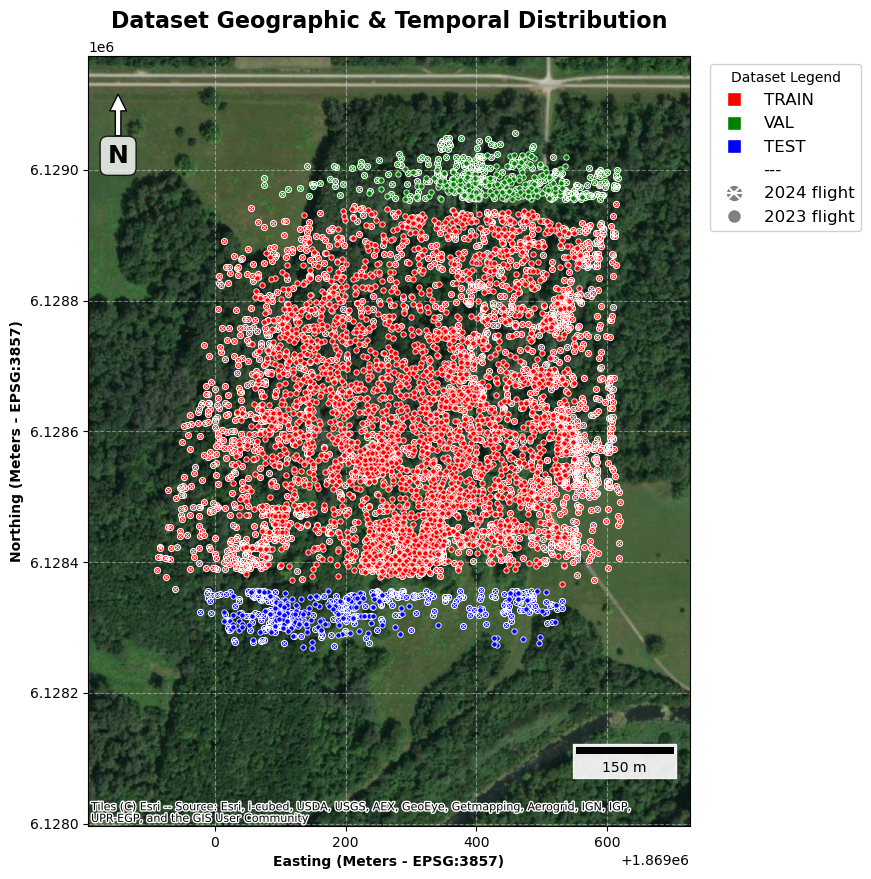

In [4]:
import os
import json
from collections import defaultdict
from pathlib import Path
from datetime import datetime

os.environ["MAPBOX_TOKEN"] = "pk.eyJ1IjoiYnJlemVtaWwiLCJhIjoiY21uc3ZrbGc0MGc5ZTJ4czY0aDg3eDQ3dSJ9.jNWndgLuFWMmmHsLrr5GrA"

import fiftyone as fo
import fiftyone.types as fot

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

def _load_slice_data_from_geojson(geojson_path):
    """Calculates the center coordinate and extracts the campaign year for each slice."""
    slice_data = {}
    if not os.path.exists(geojson_path):
        print(f"[Warning] GeoJSON not found at {geojson_path}. Map will be blank.")
        return slice_data
        
    with open(geojson_path, 'r') as f:
        data = json.load(f)
        
    for feature in data.get('features', []):
        props = feature.get('properties', {})
        geom = feature.get('geometry', {})
        
        if geom.get('type') == 'Polygon' and 'image_name' in props:
            coords = geom['coordinates'][0]
            # Simple average for centroid of bounding box coordinates
            lons = [c[0] for c in coords[:-1]] # exclude closing point
            lats = [c[1] for c in coords[:-1]]
            
            centroid_lon = sum(lons) / len(lons)
            centroid_lat = sum(lats) / len(lats)
            
            slice_data[props['image_name']] = {
                "lon": centroid_lon,
                "lat": centroid_lat,
                "campaign": props.get("campaign", "0") # Extract the campaign year
            }
            
    return slice_data

def generate_static_map(dataset, output_path: Path, show_grid=False, base_marker_size=15):
    """
    Generates a publication-ready cartographic map of the dataset's geographic and temporal distribution.

    Args:
        dataset (fiftyone.core.dataset.Dataset): The ingested FiftyOne dataset containing geographic metadata.
        output_path (Path): Destination file path for the saved PNG map.
        show_grid (bool): If True, renders an EPSG:3857 coordinate grid over the map.
        base_marker_size (int): The baseline scatter point size. Decrease to shrink the dots on the map.

    Returns:
        None: Saves the plot directly to disk.
    """
    print("\n" + "="*50)
    print(" Executing Cartographic Mapping Engine")
    print("="*50)
    
    data = []
    for sample in dataset.iter_samples():
        if sample.has_field("location") and sample.location is not None:
            ts = sample.timestamp if sample.has_field("timestamp") else None
            year = datetime.fromtimestamp(ts).year if ts else 0
            
            data.append({
                "map_group": sample.map_group, 
                "geometry": Point(sample.location.point),
                "year": year
            })
            
    if not data:
        print("[CRITICAL] Map generation aborted: No valid GPS data points found in the dataset.")
        return
        
    gdf = gpd.GeoDataFrame(data, crs="EPSG:4326").to_crs(epsg=3857)
    
    print(f"[DIAGNOSTIC] Total geospatial coordinates extracted: {len(gdf)}")
    print(f"[DIAGNOSTIC] Distribution by Map Group:")
    for group_name, count in gdf['map_group'].value_counts().items():
        print(f"  -> {group_name.upper()}: {count} points")

    max_year = gdf[gdf['year'] > 0]['year'].max() if (gdf['year'] > 0).any() else 0
    old_years_series = gdf[(gdf['year'] < max_year) & (gdf['year'] > 0)]['year']
    old_year = old_years_series.max() if not old_years_series.empty else (max_year - 1 if max_year > 0 else 0)
    
    print(f"[DIAGNOSTIC] Temporal spans identified - Newest: {max_year}, Older layer: {old_year}")

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.margins(0.15)
    
    colors = {
        "train": "red", 
        "val": "green", 
        "test": "blue", 
        "ghost": "#7f8c8d", 
        "no_footprint": "magenta",
        "excluded_orphan": "orange"
    }
    
    for map_group, group in gdf.groupby("map_group"):
        base_color = colors.get(map_group, "black")
        
        is_dropped = (map_group in ["ghost", "excluded_orphan"])
        alpha_val = 0.60 if is_dropped else 1.0
        edge_color = "grey" if is_dropped else "white"
        
        # Plot Newer Data (Now with the 'x' overlay)
        new_group = group[group['year'] >= max_year]
        if not new_group.empty:
            new_group.plot(
                ax=ax, 
                color=base_color, 
                marker='o', 
                markersize=base_marker_size * 1.25, 
                edgecolor=edge_color, 
                linewidth=0.8, 
                alpha=alpha_val
            )
            new_group.plot(
                ax=ax, 
                color="white" if not is_dropped else "#e0e0e0", 
                marker='x', 
                markersize=base_marker_size * 0.3, 
                linewidth=0.6, 
                alpha=alpha_val
            )
            
        # Plot Older Data (Now just the plain dot)
        old_group = group[(group['year'] < max_year) & (group['year'] > 0)]
        if not old_group.empty:
            old_group.plot(
                ax=ax, 
                color=base_color, 
                marker='o', 
                markersize=base_marker_size, 
                edgecolor=edge_color, 
                linewidth=0.6, 
                alpha=alpha_val
            )
        
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - ((ymax - ymin) * 0.15), ymax)

    print("[INFO] Requesting basemap from Mapbox/Esri servers...")
    try:
        ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)
        print("[INFO] Basemap rendered successfully.")
    except Exception as e:
        print(f"[WARNING] Basemap download failed. Check network or EPSG limits. Error: {e}")
        
    ax.annotate('N', xy=(0.05, 0.95), xytext=(0.05, 0.87),
                arrowprops=dict(facecolor='white', edgecolor='black', width=4, headwidth=12),
                ha='center', va='center', fontsize=18, fontweight='bold', color='black',
                xycoords=ax.transAxes, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

    scalebar = ScaleBar(1, "m", length_fraction=0.2, location="lower right", 
                        box_alpha=0.9, bbox_to_anchor=(0.98, 0.06), bbox_transform=ax.transAxes)
    ax.add_artist(scalebar)
    
    handles = []
    labels = []
    
    for map_group, color in colors.items():
        if map_group in gdf['map_group'].unique():
            if map_group == "ghost":
                handles.append(Line2D([0], [0], marker='s', color='w', markerfacecolor=color, markersize=10, alpha=0.4))
                labels.append("DROPPED BUFFER")
            elif map_group == "no_footprint":
                handles.append(Line2D([0], [0], marker='s', color='w', markerfacecolor=color, markersize=10))
                labels.append("MISSING FOOTPRINT (TRAIN)")
            elif map_group == "excluded_orphan":
                handles.append(Line2D([0], [0], marker='s', color='w', markerfacecolor=color, markersize=10, alpha=0.4))
                labels.append("EXCLUDED ORPHAN")
            else:
                handles.append(Line2D([0], [0], marker='s', color='w', markerfacecolor=color, markersize=10))
                labels.append(map_group.upper())
            
    handles.append(Line2D([0], [0], marker='', color='w', markerfacecolor='none', markersize=0))
    labels.append("---")
    
    # Legend update: Max year (2024) gets the cross
    layered_new_marker = (
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=12),
        Line2D([0], [0], marker='x', color='w', markeredgecolor='white', markeredgewidth=1.5, markersize=8)
    )
    handles.append(layered_new_marker)
    labels.append(f"{int(max_year)} flight")
    
    # Legend update: Old year (2023) gets the dot
    handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10))
    labels.append(f"{int(old_year)} flight")

    ax.legend(
        handles=handles, labels=labels, title="Dataset Legend", 
        bbox_to_anchor=(1.02, 1), loc="upper left", framealpha=0.9, 
        fontsize=12, handler_map={tuple: HandlerTuple(ndivide=1)}
    )

    if show_grid:
        ax.grid(True, linestyle="--", color="white", alpha=0.4)
        ax.tick_params(colors='black')
        ax.set_xlabel("Easting (Meters - EPSG:3857)", fontsize=10, fontweight='bold')
        ax.set_ylabel("Northing (Meters - EPSG:3857)", fontsize=10, fontweight='bold')
    else:
        ax.set_axis_off()
    
    ax.set_title("Dataset Geographic & Temporal Distribution", fontsize=16, fontweight='bold', pad=20)
    
    print(f"[INFO] Writing map image to disk...")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"[SUCCESS] Publication-ready map saved to: {output_path.absolute()}")
    print("="*50 + "\n")

def load_and_visualize_dataset(folder_path: str, geojson_path: str, dataset_name: str = "yolo_dataset", show_grid=False, show_excluded_orphans=True):
    folder_path = Path(folder_path)
    yaml_path = folder_path / "data.yaml"
    
    source_images_dir = Path(r"C:\Users\emilb\_data\sliced_dataset\images") 
    dropped_log_path = folder_path / "dropped_images.txt"
    missing_footprints_path = folder_path / "missing_footprints.txt"
    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
    
    print("="*50)
    print(" Starting FiftyOne Dataset Ingestion")
    print("="*50)
    
    if not yaml_path.exists():
        print(f"[Error] Configuration file missing: {yaml_path}")
        return
        
    if dataset_name in fo.list_datasets():
        fo.delete_dataset(dataset_name)
        
    dataset = fo.Dataset(name=dataset_name)
    dataset.add_sample_field("split", fo.StringField)
    dataset.add_sample_field("map_group", fo.StringField)
    dataset.add_sample_field("timestamp", fo.FloatField)
    dataset.add_sample_field("campaign", fo.StringField)

    loaded_splits = []
    for split in ["train", "val", "test"]:
        try:
            dataset.add_dir(
                dataset_dir=str(folder_path),
                yaml_path=str(yaml_path),
                dataset_type=fot.YOLOv5Dataset,
                split=split,
                tags=[split],
            )
            loaded_splits.append(split)
        except Exception as e:
            print(f"  [Error] Split '{split}' failed to load: {e}")

    # Load spatial slice data and campaign years
    slice_metadata = _load_slice_data_from_geojson(geojson_path)

    missing_footprints = set()
    if missing_footprints_path.exists():
        with open(missing_footprints_path, "r") as f:
            missing_footprints = {line.strip() for line in f if line.strip()}

    if source_images_dir.exists():
        print("\n[Progress] Parsing logs for mapping injection...")
        
        dropped_stems = set()
        if dropped_log_path.exists():
            with open(dropped_log_path, "r") as f:
                dropped_stems = {line.strip() for line in f if line.strip()}
        
        loaded_stems = {Path(s.filepath).stem for s in dataset}
        injected_samples = []
        ghost_count = 0
        orphan_count = 0
        
        # Searching through all subdirectories in the sliced_dataset/images folder
        for root, _, files in os.walk(source_images_dir):
            for file_name in files:
                p = Path(root) / file_name
                if p.suffix not in IMAGE_EXTENSIONS:
                    continue
                    
                if p.stem in dropped_stems:
                    sample = fo.Sample(filepath=str(p), tags=["ghost"])
                    sample["split"] = "ghost"
                    injected_samples.append(sample)
                    ghost_count += 1
                    
                elif show_excluded_orphans and p.stem in missing_footprints and p.stem not in loaded_stems:
                    sample = fo.Sample(filepath=str(p), tags=["excluded_orphan", "no_footprint"])
                    sample["split"] = "excluded"
                    injected_samples.append(sample)
                    orphan_count += 1
                
        if injected_samples:
            dataset.add_samples(injected_samples)
            if ghost_count > 0:
                print(f"[INFO] Injected {ghost_count} boundary buffer samples for map visualization.")
            if orphan_count > 0:
                print(f"[INFO] Injected {orphan_count} excluded orphan samples for map visualization.")

    print("\n[Progress] Assigning Coordinates to metadata and calculating stats...")
    has_gps = False
    stats = defaultdict(lambda: {"bg": 0, "fg": 0})
    campaign_stats = defaultdict(int)
    campaign_split_stats = defaultdict(lambda: defaultdict(int)) # NEW: Nested counter for Splits + Campaigns
    
    for sample in dataset.iter_samples(progress=True):
        if sample.tags and "excluded_orphan" in sample.tags:
            split_name = "excluded"
        else:
            split_name = sample.tags[0] if sample.tags else "unknown"
            
        sample["split"] = split_name
        
        file_stem = Path(sample.filepath).stem
        if "excluded_orphan" in sample.tags:
            sample["map_group"] = "excluded_orphan"
        elif file_stem in missing_footprints:
            sample.tags.append("no_footprint")
            sample["map_group"] = "no_footprint"
        else:
            sample["map_group"] = split_name

        has_detections = (
            sample.has_field("ground_truth") and 
            sample.ground_truth is not None and 
            hasattr(sample.ground_truth, "detections") and 
            len(sample.ground_truth.detections) > 0
        )
        
        stat_key = "fg" if has_detections else "bg"
        stats["total"][stat_key] += 1
        stats[split_name][stat_key] += 1

        campaign_str = "Unknown" 
        
        # Use GeoJSON coordinates and campaign year instead of EXIF
        if file_stem in slice_metadata:
            lon = slice_metadata[file_stem]["lon"]
            lat = slice_metadata[file_stem]["lat"]
            sample["location"] = fo.GeoLocation(point=(lon, lat))
            has_gps = True
            
            # Reconstruct a valid timestamp from the campaign year
            campaign_str = str(slice_metadata[file_stem]["campaign"])
            if campaign_str.isdigit():
                # Creates a timestamp for Jan 1st of the specific campaign year
                sample["timestamp"] = datetime(int(campaign_str), 1, 1).timestamp()
                
        # Save campaign year to sample and update counters
        sample["campaign"] = campaign_str
        campaign_stats[campaign_str] += 1
        campaign_split_stats[split_name][campaign_str] += 1 # NEW: Increment split-specific counter
            
        sample.save()
    
    print("\n" + "="*50)
    print("                DATASET OVERVIEW")
    print("="*50)
    print(f"Total Samples Ingested: {len(dataset)}")
    
    print("\n--- Target Distribution (Foreground vs Background) ---")
    for s in loaded_splits:
        print(f"    [{s.upper()}] Foreground: {stats[s]['fg']} | Background: {stats[s]['bg']}")
        
    if "ghost" in stats:
        print(f"    [DROPPED BUFFER] Map-Only Points: {stats['ghost']['fg'] + stats['ghost']['bg']}")
    if "excluded" in stats:
        print(f"    [EXCLUDED ORPHANS] Map-Only Points: {stats['excluded']['fg'] + stats['excluded']['bg']}")

    print("\n--- Temporal Distribution (Overall) ---")
    for camp, count in sorted(campaign_stats.items()):
        print(f"    [{camp}] Total Slices: {count}")

    print("\n--- Split Breakdown by Campaign ---")
    for s in loaded_splits:
        print(f"    [{s.upper()}]")
        for camp, count in sorted(campaign_split_stats[s].items()):
            print(f"        -> {camp}: {count} slices")
            
    # Also print breakdown for ghosts/excluded if they exist
    for extra_split in ["ghost", "excluded"]:
        if extra_split in campaign_split_stats:
            print(f"    [{extra_split.upper()}]")
            for camp, count in sorted(campaign_split_stats[extra_split].items()):
                print(f"        -> {camp}: {count} slices")
                
    print("="*50 + "\n")

    if has_gps:
        map_output = folder_path / "geostrat_dataset_map.png"
        generate_static_map(dataset, output_path=map_output, show_grid=show_grid, base_marker_size=15)
    
    spaces = fo.Space(children=[
        fo.Panel(type="Samples"),
        fo.Panel(type="Map", state={"locationField": "location"})
    ]) if has_gps else None
    
    print("[Progress] Starting FiftyOne server...")
    session = fo.launch_app(dataset, auto=False, spaces=spaces)

    try:
        session.wait()
    except KeyboardInterrupt:
        print("\n[Progress] Shutting down FiftyOne server.")

if __name__ == "__main__":
    load_and_visualize_dataset(
        folder_path=r"C:\Users\emilb\_data\dataset_fin\sliced_split_dataset", 
        geojson_path=r"C:\Users\emilb\_data\dataset_fin\sliced_dataset_edge_coordinates\image_footprints.geojson",
        show_grid=True,
        show_excluded_orphans=True
    )

Average slice area: 404.96 square meters


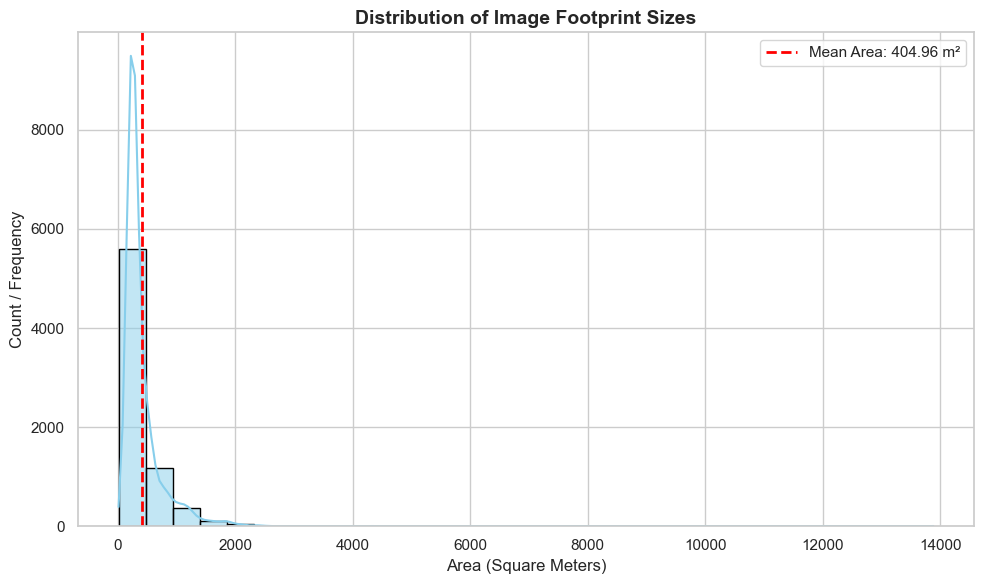

In [1]:
#tbd: check flight height etc (is it the same - how does resolution change the behaviour?)

import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
gdf = gpd.read_file(r"C:\Users\emilb\_data\dataset_fin\sliced_dataset_edge_coordinates\image_footprints.geojson")

# Project to a metric CRS
gdf_metric = gdf.to_crs(epsg=3857)

# Calculate area for each footprint (in square meters)
gdf_metric['area_m2'] = gdf_metric.area
average_area = gdf_metric['area_m2'].mean()

print(f"Average slice area: {average_area:.2f} square meters")

# --- Plotting the Histogram ---
# Set standard stock style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot histogram with a kernel density estimate (KDE) curve
sns.histplot(data=gdf_metric, x='area_m2', bins=30, kde=True, color="skyblue", edgecolor="black")

# Add a vertical line for the mean
plt.axvline(average_area, color='red', linestyle='dashed', linewidth=2, 
            label=f'Mean Area: {average_area:.2f} m²')

# Labels and title
plt.title("Distribution of Image Footprint Sizes", fontsize=14, fontweight='bold')
plt.xlabel("Area (Square Meters)", fontsize=12)
plt.ylabel("Count / Frequency", fontsize=12)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()